# OEM (val.json) - Visualizacao de Episodio

Este notebook carrega um episodio few-shot do split `val` (OEM), executa inferencia com um checkpoint do `fs-cs` e monta o painel:

- Linha 1: imagem original | suporte 1 | suporte 2 | ...
- Linha 2: GT original | mascara 1 | mascara 2 | ... | predicao

Edite a celula de configuracao antes de executar.

In [1]:
import os
import sys
from types import SimpleNamespace

import numpy as np
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

PROJECT_ROOT = os.path.abspath('.')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from data.oem import DatasetOEM
from data.dataset import FSCSDatasetModule
from model.asnet import AttentiveSqueezeNetwork
from model.panet import PrototypeAlignmentNetwork
from model.pfenet import PriorGuidedFeatureEnrichmentNetwork
from model.hsnet import HypercorrSqueezeNetwork
from model.asnethm import AttentiveSqueezeNetworkHM

MODEL_DICT = {
    'panet': PrototypeAlignmentNetwork,
    'pfenet': PriorGuidedFeatureEnrichmentNetwork,
    'hsnet': HypercorrSqueezeNetwork,
    'asnethm': AttentiveSqueezeNetworkHM,
    'asnet': AttentiveSqueezeNetwork,
}

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('DEVICE:', DEVICE)

DEVICE: cuda


In [8]:
# =========================
# CONFIGURACAO (edite aqui)
# =========================
CFG = {
    'datapath': '/scratch/matheuspimenta/oem',
    'method': 'asnet',  # panet | pfenet | hsnet | asnet | asnethm
    'backbone': 'resnet101',
    'fold': 0,
    'way': 2,
    'shot': 1,
    'bgclass': 0,
    'bgd': True,
    'weak': False,
    'rdn_sup': False,
    'benchmark': 'oem',
    'lr': 1e-3,
    'niter': 2000,
    'bsz': 1,
    'nowandb': True,
    'eval': True,
    'resume': False,
    'vis': False,
    'logpath': 'debug-notebook',
    'ckptpath': 'logs/pascal/fold0/resnet101/asnet/best_model.ckpt',

    'oem_train_list': 'train.txt',
    'oem_val_json': 'val.json',
    'oem_test_json': 'test.json',
    'oem_crop_size': 400,
    'support_strategy': 'random',
    'support_area_cache': 'auto',
    'support_similarity_cache': 'auto',
    'support_similarity_size': 32,
    'oem_sw_enable': False,
    'oem_sw_tile': 400,
    'oem_sw_stride': 312,

    'episode_index': 10,
    'seed': 0,
}

torch.manual_seed(CFG['seed'])
np.random.seed(CFG['seed'])
args = SimpleNamespace(**CFG)

if not os.path.exists(args.ckptpath):
    raise FileNotFoundError(f'Checkpoint nao encontrado: {args.ckptpath}')

print('method:', args.method)
print('ckpt:', args.ckptpath)

method: asnet
ckpt: logs/pascal/fold0/resnet101/asnet/best_model.ckpt


In [9]:
dm = FSCSDatasetModule(args, img_size=400)

val_dataset = DatasetOEM(
    datapath=args.datapath,
    fold=args.fold,
    transform=dm.transform,
    split='val',
    way=args.way,
    shot=args.shot,
    bgd=args.bgd,
    rdn_sup=args.rdn_sup,
    oem_train_list=args.oem_train_list,
    oem_val_json=args.oem_val_json,
    oem_test_json=args.oem_test_json,
    oem_crop_size=args.oem_crop_size,
    support_strategy=args.support_strategy,
    support_area_cache=args.support_area_cache,
    support_similarity_cache=args.support_similarity_cache,
    support_similarity_size=args.support_similarity_size,
)

val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=0)
print('len(val_dataset):', len(val_dataset))

[val] query entries: 30 (with label: 30, without label: 0)
[val] support entries per class: 8:5, 9:5, 10:5, 11:5
Total val images are : 20
len(val_dataset): 1000


In [10]:
model_class = MODEL_DICT[args.method]
model = model_class.load_from_checkpoint(args.ckptpath, args=args)
model = model.to(DEVICE)
model.eval()
print('Modelo carregado:', model.__class__.__name__)

Modelo carregado: AttentiveSqueezeNetwork


In [11]:
MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def tensor_img_to_rgb01(t):
    x = t.detach().cpu().float().numpy().transpose(1, 2, 0)
    x = x * STD + MEAN
    return np.clip(x, 0.0, 1.0)

def tensor_raw_to_rgb01(t):
    x = t.detach().cpu().float().numpy().transpose(1, 2, 0)
    return np.clip(x / 255.0, 0.0, 1.0)

def to_device_batch(batch, device):
    out = {}
    for k, v in batch.items():
        out[k] = v.to(device) if torch.is_tensor(v) else v
    return out

Episode: 10
query_name: valset/labels/christchurch_39.tif
support_classes: [10, 8]


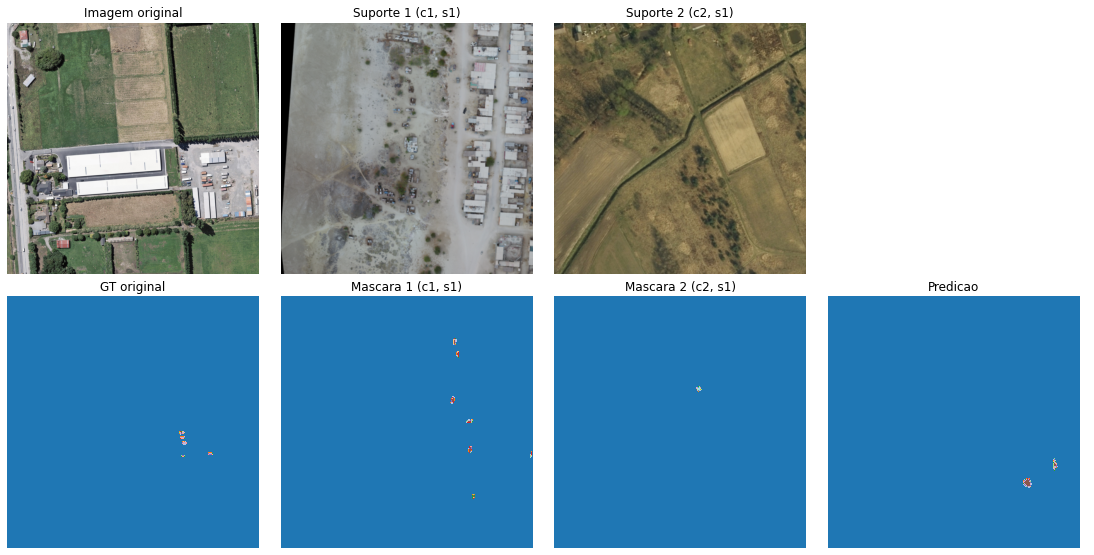

In [12]:
target_idx = int(args.episode_index)
if target_idx < 0:
    raise ValueError('episode_index deve ser >= 0')

selected_batch = None
for i, b in enumerate(val_loader):
    if i == target_idx:
        selected_batch = b
        break

if selected_batch is None:
    raise IndexError(f'episode_index {target_idx} fora do intervalo [0, {len(val_dataset)-1}]')

print('Episode:', target_idx)
print('query_name:', selected_batch['query_name'][0])
# print('support_names shape:', tuple(selected_batch['support_names'].shape))
print('support_classes:', selected_batch['support_classes'][0].tolist())

batch_gpu = to_device_batch(selected_batch, DEVICE)
with torch.no_grad():
    pred_cls, pred_seg = model.predict_mask_nshot(batch_gpu, args.shot)

pred_seg = pred_seg.detach().cpu()[0]
query_gt = selected_batch['query_mask'][0].detach().cpu()

if 'query_img_raw' in selected_batch:
    query_rgb = tensor_raw_to_rgb01(selected_batch['query_img_raw'][0])
else:
    query_rgb = tensor_img_to_rgb01(selected_batch['query_img'][0])

support_imgs = selected_batch['support_imgs'][0]
support_masks = selected_batch['support_masks'][0]

support_slots = []
for c in range(support_imgs.shape[0]):
    for s in range(support_imgs.shape[1]):
        support_slots.append((
            tensor_img_to_rgb01(support_imgs[c, s]),
            support_masks[c, s].detach().cpu().numpy(),
            c + 1,
            s + 1,
        ))

n_support = len(support_slots)
n_cols = n_support + 2

mask_max = int(max(
    query_gt.max().item(),
    pred_seg.max().item(),
    max(int(np.max(m)) for _, m, _, _ in support_slots) if n_support > 0 else 1
))
mask_max = max(mask_max, 1)

fig, axes = plt.subplots(2, n_cols, figsize=(3.8 * n_cols, 7.6), constrained_layout=True)

axes[0, 0].imshow(query_rgb)
axes[0, 0].set_title('Imagem original')
axes[0, 0].axis('off')

for i, (simg, smask, cidx, sidx) in enumerate(support_slots, start=1):
    axes[0, i].imshow(simg)
    axes[0, i].set_title(f'Suporte {i} (c{cidx}, s{sidx})')
    axes[0, i].axis('off')

axes[0, -1].axis('off')

axes[1, 0].imshow(query_gt.numpy(), cmap='tab20', vmin=0, vmax=mask_max)
axes[1, 0].set_title('GT original')
axes[1, 0].axis('off')

for i, (_, smask, cidx, sidx) in enumerate(support_slots, start=1):
    axes[1, i].imshow(smask, cmap='tab20', vmin=0, vmax=mask_max)
    axes[1, i].set_title(f'Mascara {i} (c{cidx}, s{sidx})')
    axes[1, i].axis('off')

axes[1, -1].imshow(pred_seg.numpy(), cmap='tab20', vmin=0, vmax=mask_max)
axes[1, -1].set_title('Predicao')
axes[1, -1].axis('off')

plt.show()

In [ ]:
# (Opcional) salve a figura gerada
# fig.savefig('debug_episode_val_oem.png', dpi=150, bbox_inches='tight')